# KNN avec PCA et LDA

Ce notebook implémente deux pipelines de classification KNN, l'un avec une réduction de dimension par PCA et l'autre par LDA. On compare les deux approches sur le même jeu de données.

## Imports

On importe toutes les bibliothèques nécessaires pour les deux pipelines.

In [1]:
# pyright: ignore
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from import_ipynb import NotebookFinder  # type: ignore
import importlib
import joblib
import os
import pandas as pd
from huggingface_hub import hf_hub_download
import shutil
from import_ipynb import NotebookFinder  # type: ignore
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score
import importlib
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import numpy as np
import json
import numpy as np
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output
from tenacity import retry, stop_after_attempt, wait_exponential
import asyncio

## Chargement des modules utilitaires

On définit les chemins vers les dossiers du projet et on charge les modules `metrics` et `prints` qui contiennent les fonctions d'évaluation et d'affichage.

Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Tools\python\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Using the latest cached version of the dataset since PAR8/chest-xray-pneumonia couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Aïda\.cache\huggingface\datasets\PAR8___chest-xray-pneumonia\default\0.0.0\42d3b32e6fc8f1c1974fd14f23bb49e7a130b801 (last modified on Mon Mar  9 21:58:36 2026).



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


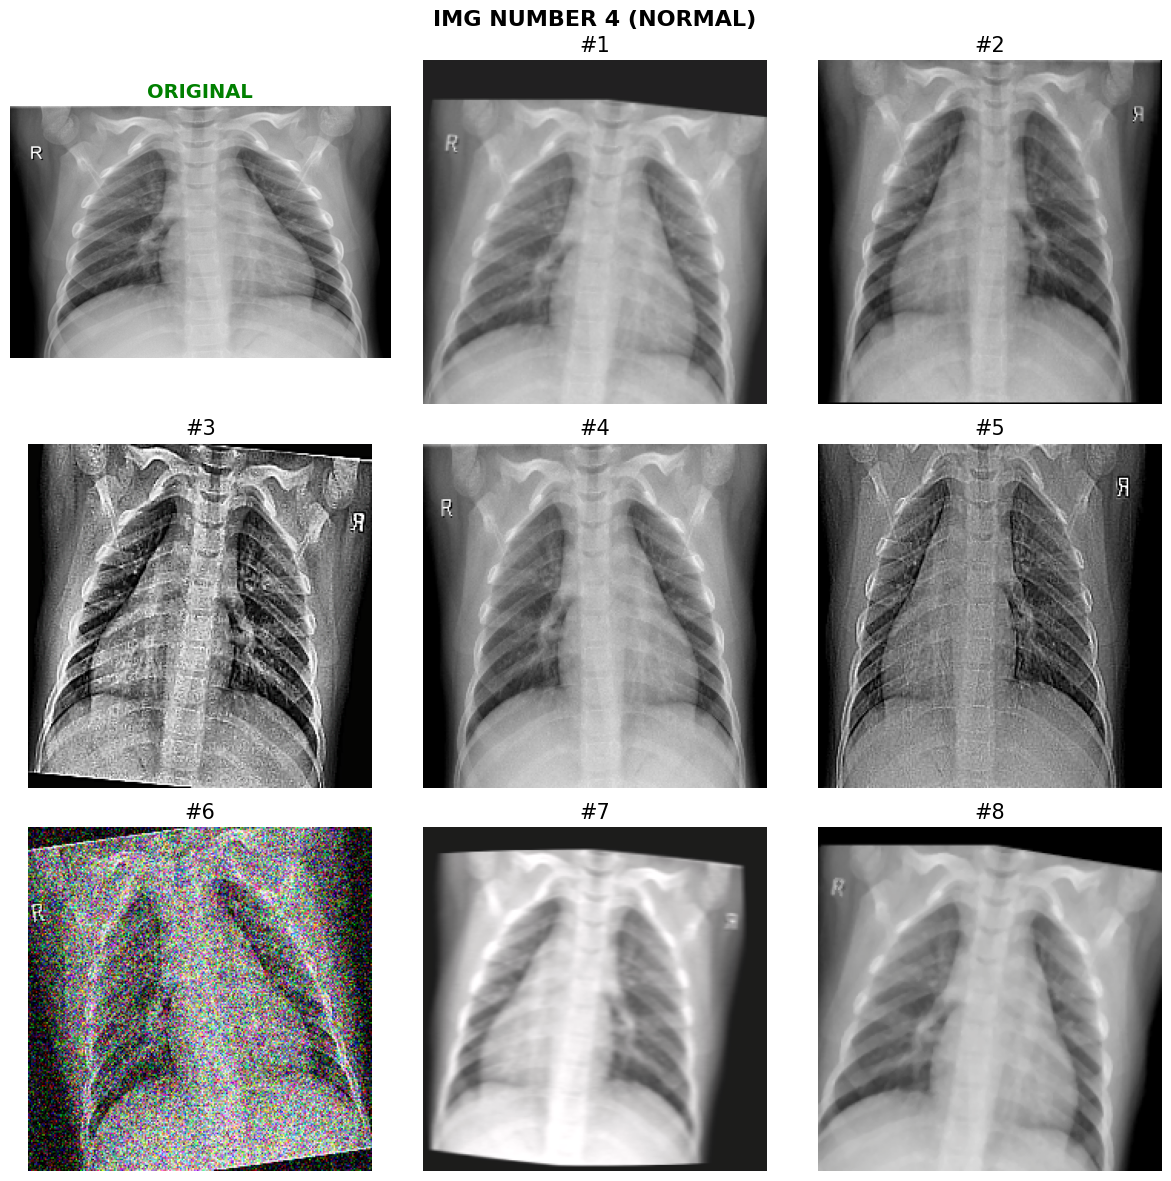


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [0, 1, 1, 2, 1, 1, 1, 1, 2, 0]
Label distribution: [10, 14, 8]


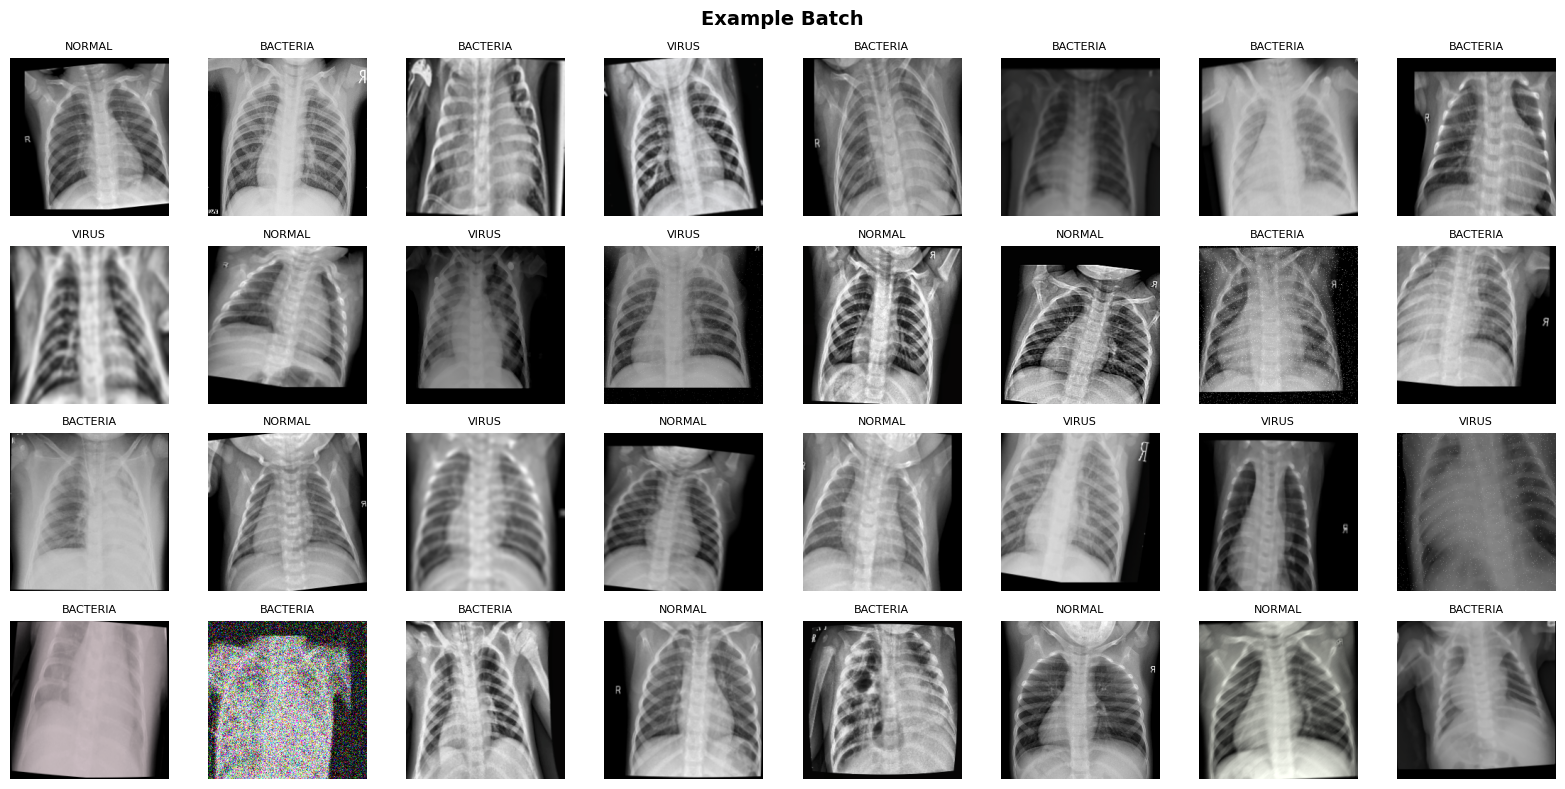

In [2]:
# Retrouver les dossiers
root = r"C:\Travaux\Epitech\Zoidberg2.0"
run_dir = os.path.join(root, "pneumonia_knn" ,"model", "run")
dataset_dir = os.path.join(root, "pneumonia_knn" ,"model", "dataset")
# charger les fichiers
# --- on_the_fly_augmentation.ipynb
spec_on_the_fly_augmentation = NotebookFinder().find_spec("on_the_fly_augmentation", [root])
on_the_fly_augmentation = importlib.util.module_from_spec(spec_on_the_fly_augmentation)
spec_on_the_fly_augmentation.loader.exec_module(on_the_fly_augmentation)

# Test

In [3]:
def apply_dataset_to_array(dataset, name):
    X = []
    y = []
    for example in tqdm(dataset, desc=f"Processing {name} dataset"):
        img_tensor = example['image']
        img_flattened = np.array(img_tensor).flatten()
        X.append(img_flattened)
        y.append(example['label'])
    return np.array(X), np.array(y)

# Test

In [4]:
def true_positives_by_class_png(y_test, y_pred, implementation_name, output_path):
    classes = ['NORMAL', 'BACTERIA', 'VIRUS']
    cm = confusion_matrix(y_test, y_pred)
    
    # Les vrais positifs sont sur la diagonale
    tp = cm.diagonal()
    total = cm.sum(axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    
    x = np.arange(len(classes))
    bars_tp    = ax.bar(x - 0.2, tp,    width=0.4, label='Vrais positifs', color='#22a05a', alpha=0.8)
    bars_total = ax.bar(x + 0.2, total, width=0.4, label='Total réel',     color='#378ADD', alpha=0.8)
    
    # Afficher les valeurs sur les barres
    for bar in bars_tp:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontsize=9)
    for bar in bars_total:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylabel("Nombre d'images", fontsize=9)
    ax.set_title(f"Vrais positifs par classe — {implementation_name}", fontsize=11)
    ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.05)

# Test

In [5]:
def true_positives_by_class_json(y_test, y_pred, implementation_name, output_path):
    classes = ['NORMAL', 'BACTERIA', 'VIRUS']
    cm = confusion_matrix(y_test, y_pred)
    
    tp = cm.diagonal()
    total = cm.sum(axis=1)
    
    results = {
        "implementation": implementation_name,
        "classes": {
            cls: {
                "true_positives": int(tp[i]),
                "total": int(total[i])
            }
            for i, cls in enumerate(classes)
        }
    }
    
    with open(output_path, "w") as f:
        json.dump(results, f, indent=4)

# Test

In [6]:
def cross_validation_png(grid, implementation_name, output_path):
    results = pd.DataFrame(grid.cv_results_)  # ← ajoute cette ligne
    # Sélectionner les colonnes clés
    table_df = results[[
        'params',
        'mean_test_accuracy',
        'mean_test_precision',
        'mean_test_recall',
        'mean_test_f1',
        'mean_test_roc_auc',
        'rank_test_accuracy'
    ]].copy()
    table_df.insert(0, 'Index CV', [f'#{i+1}' for i in range(len(table_df))])  # ← ici

    # Afficher seulement l'index dans la colonne params
    table_df['params'] = [str(i+1) for i in range(len(table_df))]
    
    # Supprimer la colonne params (redondante avec Index CV)
    table_df = table_df.drop(columns=['params'])

    # Ajuster la taille en fonction du nombre de lignes et colonnes
    num_cols = len(table_df.columns)
    num_rows = len(table_df)
    fig_width = 2 + num_cols * 1.8  # largeur adaptée au nombre de colonnes
    fig_height = 1.5 + num_rows * 0.45  # hauteur adaptée au nombre de lignes
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
        colColours=['#f7f7f7'] + ['#ffffff'] * (num_cols - 1)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Trouver l'indice de la ligne avec rank_test_accuracy = 1
    rank_col_idx = table_df.columns.get_loc('rank_test_accuracy')
    best_rank_row = None
    for i in range(num_rows):
        if table_df.iloc[i, rank_col_idx] == 1:
            best_rank_row = i + 1  # +1 car la ligne 0 est l'en-tête
            break

    # Styliser l'en-tête
    for j in range(num_cols):
        table[(0, j)].set_facecolor('#40466e')
        table[(0, j)].set_text_props(weight='bold', color='white')

    # Alternance de couleur sur les lignes + surbrillance du meilleur rang
    for i in range(1, num_rows + 1):
        for j in range(num_cols):
            if i == best_rank_row:
                # Surbrillance pour le meilleur rang
                table[(i, j)].set_facecolor('#FFD700')  # Doré
                table[(i, j)].set_text_props(weight='bold')
            elif i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')

    plt.title(implementation_name + " Cross-Validation Results", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()

# Test

In [7]:
def cross_validation_json(grid, implementation_name, output_path):
    # Préparer les données à sauvegarder
    results_data = {
        'implementation': implementation_name,
        'best_params': grid.best_params_,
        'best_score': float(grid.best_score_),
        'best_index': int(grid.best_index_),
        'cv_results': {}
    }
    
    # Convertir les colonnes numpy en listes pour la sérialisation JSON
    for key, value in grid.cv_results_.items():
        if hasattr(value, 'tolist'):
            results_data['cv_results'][key] = value.tolist()
        else:
            results_data['cv_results'][key] = value
    
    # Sauvegarder en JSON
    with open(output_path, 'w') as f:
        json.dump(results_data, f, indent=4)

In [8]:
run_index = len(os.listdir(run_dir))

In [9]:
hf_token = os.getenv("KEY_HUGGING_FACE")
local_paths = [
    os.path.join(dataset_dir, "dataset_train.pkl"),
    os.path.join(dataset_dir, "dataset_val.pkl"),
    os.path.join(dataset_dir, "dataset_test.pkl")
]

def process_next(index=0):
    # On a traité tous les fichiers
    if index >= len(local_paths):
        display(widgets.HTML("<span style='color: green;'>✅ Tous les fichiers sont prêts !</span>"))
        return

    local_path = local_paths[index]
    filename = os.path.basename(local_path)

    # Si le fichier existe déjà, on passe directement au suivant
    if os.path.exists(local_path):
        process_next(index + 1)
        return

    output = widgets.Output()

    def on_click(val):
        def handler(b):
            with output:
                clear_output()
                if val == 1:
                    try:
                        display(widgets.HTML("<span style='color: green;'>Téléchargement en cours...</span>"))
                        @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
                        def download_model():
                            return hf_hub_download(
                                repo_id="Aidavef/chest-xray-pneumonia",
                                filename=f"KNN/models/v1/{filename}",
                                repo_type="model",
                                token=hf_token,
                                local_dir=dataset_dir,
                                local_files_only=False,
                                cache_dir=None
                            )
                        cached_path = download_model()
                        dest_path = os.path.join(dataset_dir, filename)
                        shutil.move(cached_path, dest_path)
                        shutil.rmtree(os.path.join(dataset_dir, "KNN"), ignore_errors=True)
                        shutil.rmtree(os.path.join(dataset_dir, ".cache"), ignore_errors=True)
                        display(widgets.HTML("<span style='color: green;'>✓ Téléchargement terminé</span>"))
                    except Exception as e:
                        display(widgets.HTML(f"<span style='color: red;'>Erreur : {e}</span>"))

                elif val == 2:
                    display(widgets.HTML("<span style='color: green;'>Preprocessing en cours...</span>"))
                    if filename == "dataset_train.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.train_data,"train"), local_path)
                    elif filename == "dataset_test.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.test_data,"test"), local_path)
                    elif filename == "dataset_val.pkl":
                        joblib.dump(apply_dataset_to_array(on_the_fly_augmentation.val_data,"val"), local_path)
                    display(widgets.HTML("<span style='color: green;'>✓ Preprocessing terminé</span>"))

            # ✅ On passe au fichier suivant après l'action
            process_next(index + 1)

        return handler

    btn1 = widgets.Button(description="Télécharger depuis Hugging Face (-1min)", button_style="info", layout=widgets.Layout(width="300px", margin="10px 20px 15px 20px"))
    btn2 = widgets.Button(description="Lancer le preprocessing", button_style="info", layout=widgets.Layout(width="300px", margin="10px 20px 15px 20px"))

    btn1.on_click(on_click(1))
    btn2.on_click(on_click(2))

    title = widgets.HTML(f"Le fichier <b>{filename}</b> est manquant. Que souhaitez-vous faire ?")
    box = widgets.HBox([btn1, btn2], layout=widgets.Layout(justify_content="center"))

    display(title, box, output)

process_next()

HTML(value="<span style='color: green;'>✅ Tous les fichiers sont prêts !</span>")

In [10]:
X_train, y_train = joblib.load(f'{dataset_dir}/dataset_train.pkl')
X_val, y_val = joblib.load(f'{dataset_dir}/dataset_val.pkl')
X_test, y_test = joblib.load(f'{dataset_dir}/dataset_test.pkl')

---
# Pipeline PCA + KNN

## Création du pipeline

On crée un pipeline avec deux étapes : la réduction de dimension avec PCA, puis la classification avec KNN.

Les hyperparamètres testés sont :
- `pca__n_components` : 0.95 (on garde 95% de la variance)
- `knn__n_neighbors` : 3, 5, 9
- `knn__metric` : euclidean, manhattan
- `knn__weights` : distance
- `knn__algorithm` : ball_tree

In [11]:
# Pipeline PCA + KNN
pipeline_pca = Pipeline([
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# Hyperparamètres à tester
param_grid_pca = {
    'pca__n_components': [0.95],
    'knn__n_neighbors': [3, 5, 9],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['distance'],
    'knn__algorithm': ['ball_tree']
}
# Configuration des métriques pour GridSearchCV
scoring = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, average='weighted'),
    'recall':    make_scorer(recall_score,    average='macro'),
    'f1':        make_scorer(f1_score,        average='weighted'),
    'roc_auc':   make_scorer(roc_auc_score,   response_method="predict_proba", average='macro', multi_class='ovo')
}

## GridSearchCV — PCA + KNN

On lance une recherche par grille pour trouver les meilleurs hyperparamètres. Si le fichier `.pkl` existe déjà, on le charge directement pour éviter de tout relancer.

In [12]:
file_name_pca = "knn_pca_grid_search.pkl"
state = {'dossier': None}  # dict mutable, pas besoin de global

if run_index == 0:
    display(widgets.HTML("<span style='color: green;'>Process : Cross Validation - PCA + KNN</span>"))
    grid_pca = GridSearchCV(
        estimator=pipeline_pca,
        param_grid=param_grid_pca,
        cv=2,
        scoring=scoring,
        refit='recall',
        n_jobs=1,
        verbose=2
    )
    grid_pca.fit(X_train, y_train)  # type: ignore
    save_dir = f'run_dir/run_{run_index}'
    os.makedirs(save_dir, exist_ok=True)
    joblib.dump(grid_pca, f'{save_dir}/{file_name_pca}')

else:
    fichiers = os.listdir(run_dir)

    dropdown = widgets.Dropdown(
        options=fichiers,
        description="Fichier :",
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
    confirm_btn = widgets.Button(
        description="Confirmer",
        button_style='success',
        layout=widgets.Layout(width='100px')
    )
    output = widgets.Output()

    def on_confirm(b):
        state['dossier'] = dropdown.value  # mutation du dict, visible partout
        confirm_btn.disabled = True
        with output:
            output.clear_output()
            display(widgets.HTML(f"✅ Fichier confirmé : <span style='color: blue;'>{state['dossier']}</span>"))

    confirm_btn.on_click(on_confirm)
    display(widgets.HBox([dropdown, confirm_btn]))
    display(output)

Output()

In [13]:
print(state['dossier'])  # vérifie que ce n'est plus None avant de continuer
grid_pca = joblib.load(f'{run_dir}/{state["dossier"]}/{file_name_pca}')

None


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Travaux\\Epitech\\Zoidberg2.0\\pneumonia_knn\\model\\run/None/knn_pca_grid_search.pkl'

## Transformation PCA

On applique la transformation PCA du meilleur modèle trouvé sur les données d'entraînement et de test.

In [ ]:
X_train_pca = grid_pca.best_estimator_.named_steps['pca'].transform(X_train)  # type: ignore
X_test_pca  = grid_pca.best_estimator_.named_steps['pca'].transform(X_test)   # type: ignore

## Prédictions — PCA + KNN

On génère les prédictions sur les données de test avec le meilleur pipeline PCA + KNN.

In [ ]:
knn_pca   = grid_pca.best_estimator_
y_pred_pca = knn_pca.predict(X_test)  # type: ignore

## Résultats — PCA + KNN

On affiche les résultats de la validation croisée sous forme de tableau et on les sauvegarde en JSON.

In [ ]:
cross_validation_png(grid_pca, "PCA", f'{result_dir}/run{run_id}/cross_validation_pca.png')
cross_validation_json(grid_pca, "PCA", f'{result_dir}/run{run_id}/cross_validation_pca.json')

true_positives_by_class_png(y_test, y_pred_pca, "PCA", f'{result_dir}/run{run_id}/true_positives_by_class_pca.png')
true_positives_by_class_json(y_test, y_pred_pca, "PCA", f'{result_dir}/run{run_id}/true_positives_by_class_pca.json')


---
# Pipeline LDA + KNN

## Création des pipelines

On crée deux variantes :
- **LDA seul** : StandardScaler + LDA + KNN (les données brutes nécessitent une normalisation avant LDA)
- **PCA + LDA** : LDA + KNN (les données déjà réduites par PCA n'ont plus besoin du scaler)

Les hyperparamètres testés sont :
- `knn__n_neighbors` : 3, 5, 9
- `knn__metric` : euclidean, manhattan
- `knn__weights` : distance
- `knn__algorithm` : brute

In [ ]:
# Pipeline LDA seul (avec scaler car données brutes)
pipeline_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LDA(n_components=2)),
    ('knn', KNeighborsClassifier())
])

# Pipeline PCA + LDA (pas de scaler, X_train_pca déjà normalisé)
pipeline_pca_lda = Pipeline([
    ('lda', LDA(n_components=2)),
    ('knn', KNeighborsClassifier())
])

# Hyperparamètres à tester
param_grid_lda = {
    'knn__n_neighbors': [3, 5, 9],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['distance'],
    'knn__algorithm': ['brute']
}

## GridSearchCV — LDA + KNN

Même logique que pour PCA : on lance la recherche par grille ou on charge le fichier déjà sauvegardé. La variable `implementation` permet de choisir entre `lda` et `pca_lda`.

In [ ]:
file_name_lda = 'knn_pca_lda_grid_search.pkl' if 'pca_lda' in implementation else 'knn_lda_grid_search.pkl'  # type: ignore
pipeline      = pipeline_pca_lda               if 'pca_lda' in implementation else pipeline_lda              # type: ignore

if not os.path.exists(f'{hyperparameter_dir}/{file_name_lda}'):
    prints.bold("Process : Cross Validation - LDA + KNN")
    grid_lda = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_lda,
        cv=2,
        scoring=metrics.get_scoring(),
        refit='recall',
        n_jobs=1,
        verbose=2
    )
    grid_lda.fit(X_train, y_train)  # type: ignore
    joblib.dump(grid_lda, f'{hyperparameter_dir}/{file_name_lda}')

grid_lda = joblib.load(f'{hyperparameter_dir}/{file_name_lda}')

## Transformation LDA

On applique la transformation LDA du meilleur modèle sur les données d'entraînement et de test.

In [ ]:
X_train_lda = grid_lda.best_estimator_.named_steps['lda'].transform(X_train)  # type: ignore
X_test_lda  = grid_lda.best_estimator_.named_steps['lda'].transform(X_test)   # type: ignore

## Prédictions — LDA + KNN

On génère les prédictions sur les données de test avec le meilleur pipeline LDA + KNN.

In [ ]:
knn_lda    = grid_lda.best_estimator_
y_pred_lda = knn_lda.predict(X_test)  # type: ignore

## Résultats — LDA + KNN

On affiche et sauvegarde les résultats de la validation croisée pour le pipeline LDA.

In [ ]:
cross_validation_png(grid_lda, "LDA")
cross_validation_json(grid_lda, "LDA")